# EDA — Passos Mágicos
## Análise Exploratória dos Dados — PEDE 2024 Datathon

Este notebook explora o dataset do Programa de Educação para o Desenvolvimento de Excelência (PEDE) para entender o perfil dos alunos e embasar as decisões de modelagem.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

DATA_PATH = '../data/BASE DE DADOS PEDE 2024 - DATATHON.xlsx'

# o arquivo tem 3 planilhas: PEDE2022, PEDE2023, PEDE2024
# esta celula faz a analise em cima de 2022 (planilha base)
# o pre-processamento final combina os 3 anos - ver src/preprocessing.py
df = pd.read_excel(DATA_PATH)
print(f'PEDE2022: {df.shape[0]} alunos × {df.shape[1]} colunas')
df.head(3)

## 1. Visão Geral do Dataset

In [2]:
print('=== Tipos de dados ===')
print(df.dtypes)
print('\n=== Valores nulos ===')
nulls = df.isnull().sum()
print(nulls[nulls > 0].sort_values(ascending=False))

=== Tipos de dados ===
RA                        object
Fase                       int64
Turma                     object
Nome                      object
Ano nasc                   int64
Idade 22                   int64
Gênero                    object
Ano ingresso               int64
Instituição de ensino     object
Pedra 20                  object
Pedra 21                  object
Pedra 22                  object
INDE 22                  float64
Cg                         int64
Cf                         int64
Ct                         int64
Nº Av                      int64
Avaliador1                object
Rec Av1                   object
Avaliador2                object
Rec Av2                   object
Avaliador3                object
Rec Av3                   object
Avaliador4                object
Rec Av4                   object
IAA                      float64
IEG                      float64
IPS                      float64
Rec Psicologia            object
IDA                 

In [3]:
# olhando as colunas numericas pra decidir o que incluir no modelo
# primeiro pensamos em usar tudo, mas ai percebemos o problema com IAN

print('valores unicos do IAN:')
print(sorted(df['IAN'].dropna().unique()))

print('\nIAN vs Defas - correlacao:')
print(round(df['IAN'].corr(df['Defas']), 4))

# IAN tem so 3 valores: 2.5, 5.0 e 10.0
# e correlacao de 0.84 com Defas - praticamente entrega o target
# isso significa que IAN e calculado a partir da defasagem, nao e uma feature independente
print('\nmedia do IAN por Defas:')
print(df.groupby('Defas')['IAN'].mean())

valores unicos do IAN:
[np.float64(2.5), np.float64(5.0), np.float64(10.0)]

IAN vs Defas - correlacao:
0.8384

media do IAN por Defas:
Defas
-5     2.5
-4     2.5
-3     2.5
-2     5.0
-1     5.0
 0    10.0
 1    10.0
 2    10.0
Name: IAN, dtype: float64


In [4]:
# tentativa inicial: classificacao binaria (defasado vs nao defasado)
# ficamos com isso por um tempo antes de decidir usar 3 classes

df['target_binario'] = (df['Defas'] < 0).astype(int)
print('distribuicao binaria:')
print(df['target_binario'].value_counts())
print(f"\n{df['target_binario'].mean()*100:.1f}% dos alunos estao defasados")

# o problema e que isso tratava defasagem -1 igual a -5
# sendo que a intervencao necessaria e bem diferente
# por isso optamos por 3 classes no final

distribuicao binaria:
target_binario
1    601
0    259
Name: count, dtype: int64

69.9% dos alunos estao defasados


## 2. Variável Target — Risco de Defasagem

**Defas** = diferença entre a Fase atual e a Fase ideal para a idade do aluno.

Transformamos em 3 classes de risco:
- `0` → **Sem Risco** (Defas ≥ 0)
- `1` → **Risco Médio** (Defas = -1)
- `2` → **Alto Risco** (Defas ≤ -2)

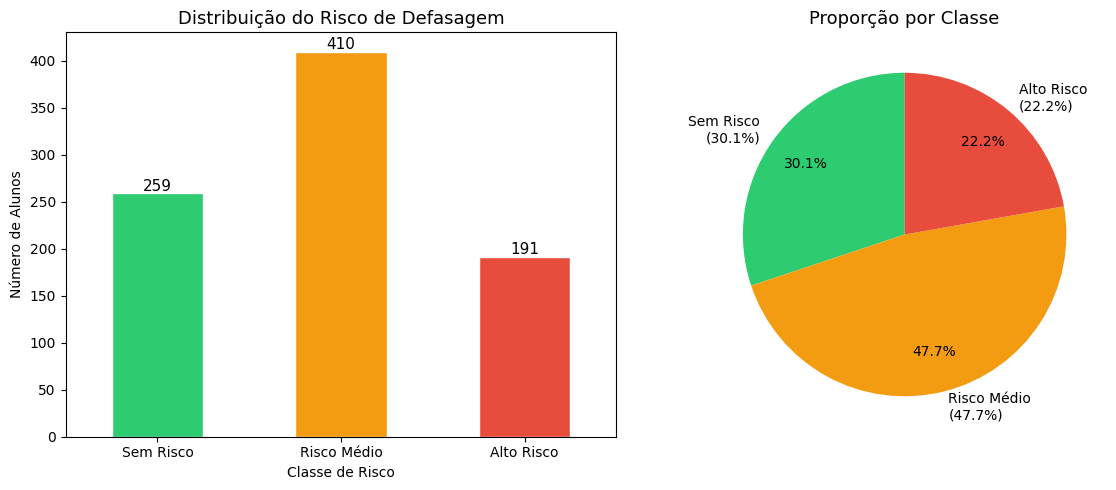


Total de alunos defasados: 601 (69.9%)


In [5]:
def classify_risk(defas):
    if defas >= 0: return 0
    elif defas == -1: return 1
    return 2

RISK_LABELS = {0: 'Sem Risco', 1: 'Risco Médio', 2: 'Alto Risco'}
RISK_COLORS = {0: '#2ECC71', 1: '#F39C12', 2: '#E74C3C'}

df['target'] = df['Defas'].apply(classify_risk)
df['risk_label'] = df['target'].map(RISK_LABELS)

counts = df['risk_label'].value_counts()
pcts   = counts / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = [RISK_COLORS[k] for k in df['target'].value_counts().sort_index().index]
df['target'].value_counts().sort_index().rename(index=RISK_LABELS).plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='white'
)
axes[0].set_title('Distribuição do Risco de Defasagem')
axes[0].set_xlabel('Classe de Risco')
axes[0].set_ylabel('Número de Alunos')
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'{int(bar.get_height())}', ha='center', fontsize=11)

wedge_colors = [RISK_COLORS[k] for k in sorted(RISK_LABELS.keys())]
axes[1].pie(
    [counts.get(v, 0) for v in RISK_LABELS.values()],
    labels=[f"{v}\n({pcts.get(v, 0):.1f}%)" for v in RISK_LABELS.values()],
    colors=wedge_colors, startangle=90, autopct='%1.1f%%', pctdistance=0.75
)
axes[1].set_title('Proporção por Classe')

plt.tight_layout()
plt.show()

print(f"\nTotal de alunos defasados: {(df['target'] > 0).sum()} ({(df['target'] > 0).mean()*100:.1f}%)")

## 3. Distribuição dos Índices Educacionais

In [6]:
# checando se Ingles vale incluir como feature
print('nulos no Ingles:', df['Inglês'].isnull().sum(), 'de', len(df))
print(f'isso e {df["Inglês"].isnull().mean()*100:.1f}% de nulos')

# 67% de nulos - nao compensa incluir
# SimpleImputer com median daria mas distorceria muito
# decidimos deixar de fora

nulos no Ingles: 577 de 860
isso e 67.1% de nulos


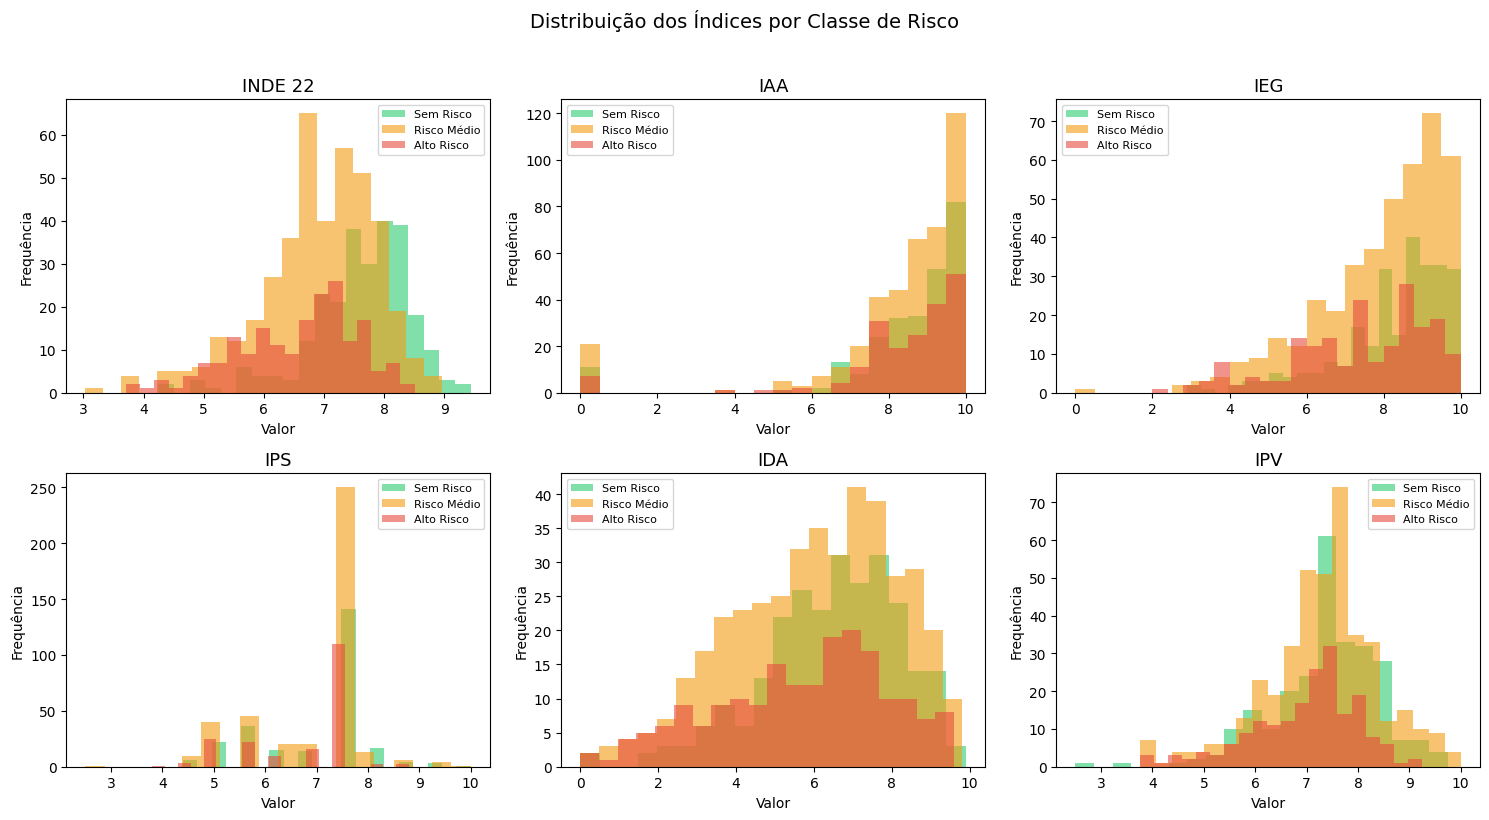

In [7]:
indices = ['INDE 22', 'IAA', 'IEG', 'IPS', 'IDA', 'IPV']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(indices):
    for cls in sorted(df['target'].unique()):
        subset = df[df['target'] == cls][col].dropna()
        axes[i].hist(subset, alpha=0.6, bins=20,
                     color=RISK_COLORS[cls], label=RISK_LABELS[cls])
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frequência')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribuição dos Índices por Classe de Risco', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Correlação das Features com a Defasagem

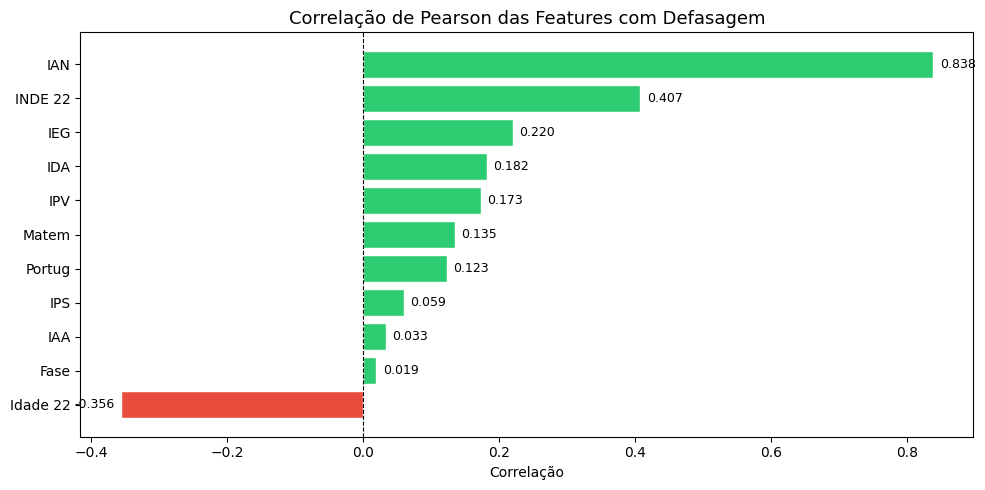

In [8]:
numeric_cols = ['INDE 22', 'IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN',
                'Matem', 'Portug', 'Fase', 'Idade 22']

correlations = df[numeric_cols].corrwith(df['Defas']).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#E74C3C' if c < 0 else '#2ECC71' for c in correlations]
bars = ax.barh(correlations.index, correlations.values, color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Correlação de Pearson das Features com Defasagem')
ax.set_xlabel('Correlação')

for bar, val in zip(bars, correlations.values):
    ax.text(val + 0.01 if val >= 0 else val - 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Distribuição por Pedra (Classificação INDE)

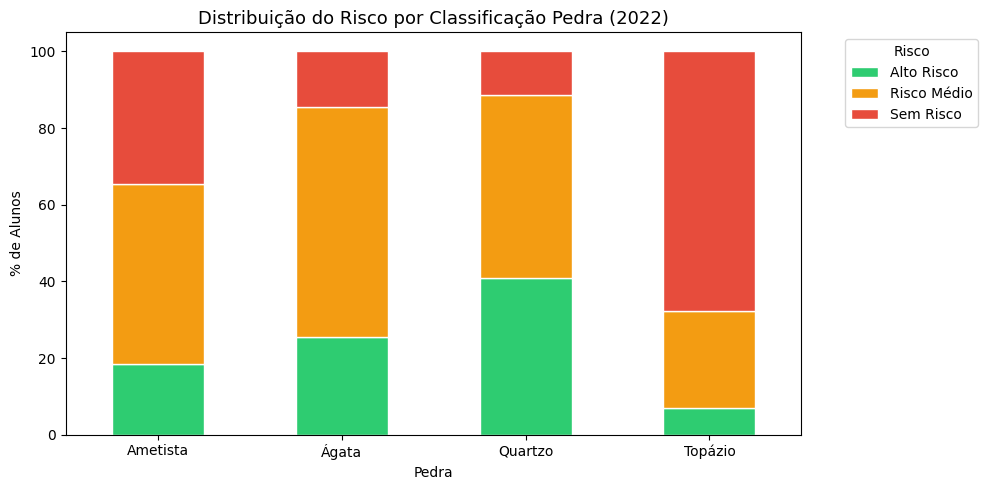

In [9]:
pedra_risk = pd.crosstab(df['Pedra 22'], df['risk_label'], normalize='index') * 100
pedra_order = ['Ametista', 'Ágata', 'Quartzo', 'Topázio']
pedra_risk = pedra_risk.reindex(pedra_order)

ax = pedra_risk.plot(
    kind='bar', stacked=True,
    color=[RISK_COLORS[k] for k in sorted(RISK_LABELS.keys())],
    figsize=(10, 5), edgecolor='white'
)
ax.set_title('Distribuição do Risco por Classificação Pedra (2022)')
ax.set_xlabel('Pedra')
ax.set_ylabel('% de Alunos')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Risco', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 6. Análise por Fase e Idade

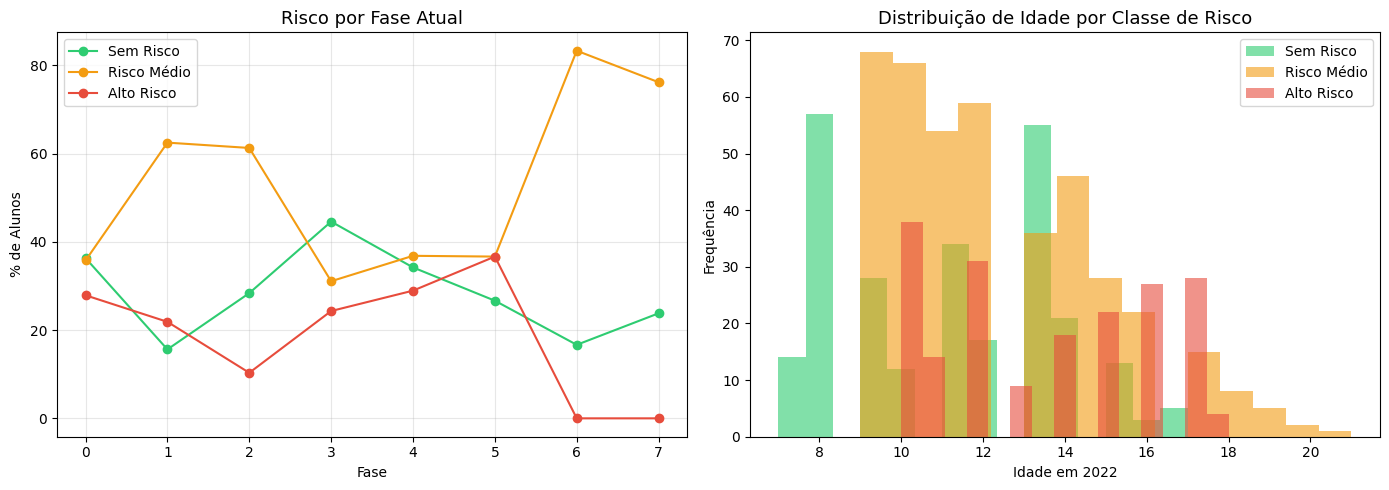

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risco por Fase
fase_risk = pd.crosstab(df['Fase'], df['risk_label'], normalize='index') * 100
for lbl, col in zip(RISK_LABELS.values(), [RISK_COLORS[k] for k in sorted(RISK_LABELS.keys())]):
    if lbl in fase_risk.columns:
        axes[0].plot(fase_risk.index, fase_risk[lbl], marker='o', label=lbl, color=col)
axes[0].set_title('Risco por Fase Atual')
axes[0].set_xlabel('Fase')
axes[0].set_ylabel('% de Alunos')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Distribuição de idade por classe
for cls in sorted(df['target'].unique()):
    subset = df[df['target'] == cls]['Idade 22'].dropna()
    axes[1].hist(subset, alpha=0.6, bins=15,
                 color=RISK_COLORS[cls], label=RISK_LABELS[cls])
axes[1].set_title('Distribuição de Idade por Classe de Risco')
axes[1].set_xlabel('Idade em 2022')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Estatísticas Descritivas por Classe

In [11]:
features = ['INDE 22', 'IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'Matem', 'Portug']
stats = df.groupby('risk_label')[features].mean().round(3)
stats.index.name = 'Risco'
stats

,INDE 22,IAA,IEG,IPS,IDA,IPV,Matem,Portug
Risco,,,,,,,,
Alto Risco,6.569,8.274,7.362,6.793,5.671,6.964,5.447,5.966
Risco Médio,6.893,8.197,7.914,6.935,6.050,7.295,5.739,6.315
Sem Risco,7.608,8.397,8.246,6.941,6.473,7.402,6.178,6.590


## 8. IPP — Índice Psicossocial Participativo (2023+)

In [ ]:
df23 = pd.read_excel(DATA_PATH, sheet_name='PEDE2023')
df24 = pd.read_excel(DATA_PATH, sheet_name='PEDE2024')

print('IPP em PEDE2022:', 'IPP' in df.columns)
print('IPP em PEDE2023:', 'IPP' in df23.columns, '— nulos:', df23['IPP'].isna().sum())
print('IPP em PEDE2024:', 'IPP' in df24.columns, '— nulos:', df24['IPP'].isna().sum())

print('\ncorrelacao IPP x Defasagem (2023):', round(df23['IPP'].corr(pd.to_numeric(df23['Defasagem'], errors='coerce')), 4))
print('correlacao IPS x Defasagem (2023):', round(df23['IPS'].corr(pd.to_numeric(df23['Defasagem'], errors='coerce')), 4))
print('correlacao IPP x IPS (2023):', round(df23['IPP'].corr(df23['IPS']), 4))
print('\nIPP e IPS nao sao o mesmo indice e possuem correlacao quase nula entre si')
print('IPP foi adicionado como feature — imputado por mediana nos registros de 2022')

## 9. Principais Conclusões

| Observação | Impacto no Modelo |
|---|---|
| **71% dos alunos estão defasados** | Classes desbalanceadas → F1-macro como métrica |
| **IAN correlação 0.84 com Defas** | Removido por data leakage |
| **Idade + Fase são preditores estruturais** | Mantidos — capturam defasagem por construção |
| **INDE 22 separa bem as classes** | Feature mais importante além da estrutura demográfica |
| **Inglês: 67% de valores nulos** | Excluído das features do modelo |
| **Topázio = menor risco** | Pedra reflete performance no INDE, validando sua inclusão |